# Sistema d'Alerta Primerenca (EWS) — Modelatge amb LightGBM

**TFG - Anàlisi i Predicció del Risc de Fracàs Acadèmic: Un Sistema d'Alerta Primerenca**  
**Enginyeria Matemàtica en Ciència de Dades**  
Universitat Pompeu Fabra - Curs 2024-25

**Uriel Cabañas Pedro**

**Tutora:** Marta Manzanares Altes

---

## Descripció

Aquest notebook implementa el **Sistema d'Alerta Primerenca (EWS)** del Capítol 6 del Treball. A partir dels datasets generats al notebook `TFG_Analisi.ipynb`, s'entrenen models de classificació binària **LightGBM** per predir el risc d'abandonament o suspens dels estudiants del curs *Fonaments de Física* 2024-25.

### Estructura del notebook

| Secció | Contingut |
|--------|-----------|
| **1. Càrrega de Dades** | Lectura dels CSVs exportats per `TFG_Analisi.ipynb` |
| **2. Imports** | Llibreries de ML i avaluació |
| **3. Preparació** | Eliminació de la variable `total_examen` (leakage) |
| **4. Model Baseline** | Entrenament amb hiperparàmetres fixos i CV estratificada |
| **4.1 Model General** | Model de comportament pur (sense notes acadèmiques) |
| **4.2 Models per Bloc** | Un model per cada bloc temporal (B1–B4) |
| **5. Importància de Variables** | Top features per gain a cada bloc |
| **6. Anàlisi SHAP** | Interpretabilitat: summary, bar, waterfall i dependence plots |
| **7. Classificació en Risc** | Simulació de les alertes emeses per cada bloc |
| **8. Optimització (Optuna)** | Cerca d'hiperparàmetres òptims amb TPE + avaluació hold-out |
| **9. Comparativa Baseline vs. Optuna** | Millora obtinguda amb l'optimització |
| **10. Exportació de Models** |

> **Prerequisit:** Cal executar primer `TFG_Analisi.ipynb` perquè aquest notebook pugui carregar els CSV generats en aquell.


## 1. Imports

In [2]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.0 MB/s eta 0:00:00


In [3]:
import json
import os

import lightgbm as lgb
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

## 2. Càrrega de Dades

Els datasets s'han generat al notebook `TFG_Analisi.ipynb` i s'han exportat com a CSV. Es carreguen ara per poder treballar-hi de manera independent.

Ajusta la variable `DATA_DIR` si els fitxers es troben en un directori diferent (per exemple, un Google Drive muntat a Colab).


In [10]:
from google.colab import drive
drive.mount('/content/drive')

#  Directori on es troben els CSVs exportats per TFG_Analisi.ipynb
DATA_DIR = "/content/drive/Shareddrives/TFG Uriel/Dades del curs FF 24-25/Dades anonimitzades/resultats/"  # Canviar segons sigui necessàri


def load_csv(filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)
    print(f"  - {filename:30s} -> {df.shape[0]:4d} files × {df.shape[1]:3d} columnes")
    return df

print("Carregant datasets...")
final_df = load_csv("final_df.csv")
b1_df = load_csv("b1.csv")
b2_df = load_csv("b2.csv")
b3_df = load_csv("b3.csv")
b4_df = load_csv("b4.csv")
qual_mtc = load_csv("qualificacions.csv")
processed_logs = load_csv("processed_logs.csv")
aval_alt = load_csv("aval_alt.csv")
id_est = load_csv("id_est.csv")
df_alt = load_csv("alt_df.csv")

print("\nCarrega completada.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carregant datasets...
  - final_df.csv                   ->  261 files × 477 columnes
  - b1.csv                         ->  260 files × 222 columnes
  - b2.csv                         ->  261 files × 331 columnes
  - b3.csv                         ->  261 files × 412 columnes
  - b4.csv                         ->  261 files × 449 columnes
  - qualificacions.csv             ->  270 files ×  67 columnes
  - processed_logs.csv             ->  261 files × 403 columnes
  - aval_alt.csv                   ->  279 files ×   2 columnes
  - id_est.csv                     ->  270 files ×   4 columnes
  - alt_df.csv                     ->  261 files × 412 columnes

Carrega completada.


## 3. Preparació: Eliminació de `total_examen`

La columna `total_examen` és una variable de **data leakage**: conté informació de la nota d'examen final, que és part del càlcul del `target`. Si no s'elimina, el model l'aprendria com a drecera trivial i no generalitzaria.

S'elimina de tots els datasets de bloc (B1–B4). El comentari del bloc final (`final_df`) es manté inactiu perquè `final_df` es fa servir en altres anàlisis.


In [11]:
#final_df.drop("total_examen", axis = 1, inplace = True)
b1_df.drop("total_examen", axis = 1, inplace = True)
b2_df.drop("total_examen", axis = 1, inplace = True)
b3_df.drop("total_examen", axis = 1, inplace = True)
b4_df.drop("total_examen", axis = 1, inplace = True)

# Entrenament de Models LightGBM

### Funció d'entrenament amb validació creuada

La funció `entrenar_model_lgbm` entrena un model LightGBM fent servir **Stratified K-Fold Cross Validation** (5 folds per defecte). Punts destacats:

- **`scale_pos_weight`**: compensa el desequilibri de classes (hi ha més aprovats que suspesos) donant més pes als falsos negatius.
- **Threshold ajustable**: permet calibrar el punt de tall de probabilitat per maximitzar el recall dels estudiants en risc.
- S'emmagatzema el millor model de cada fold (el que obté el F1 més alt) per a anàlisis posteriors.
- Es genera una **matriu de confusió agregada** sobre tots els folds.


In [12]:
# Hiperparàmetres comuns per a tots els models
params_lgbm = {
    "objective": "binary",
    "boosting_type": "rf",
    "num_leaves": 5,
    "force_row_wise": True,
    "learning_rate": 0.5,
    "metric": "binary_logloss",
    "bagging_fraction": 0.8,
    "feature_fraction": 0.8,
    "verbose": -1,
}

def entrenar_model_lgbm(df_bloc, nom, drop_cols=None, threshold=0.5, n_splits=5):
    """
    Entrena un model LightGBM amb validació creuada estratificada (Stratified K-Fold).
    Incorpora scale_pos_weight per compensar el desequilibri de classes.
    Retorna: (millor_model, diccionari_de_mètriques_mitjanes)
    """
    cols_drop = ["target"] + (drop_cols or [])
    X = df_bloc.drop(columns=[c for c in cols_drop if c in df_bloc.columns])
    y = df_bloc["target"].reset_index(drop=True)
    X = X.reset_index(drop=True)
    X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

    # Correcció del desequilibri de classes (scale_pos_weight = #negatiu / #positiu)
    n_neg = int((y == 0).sum())
    n_pos = int((y == 1).sum())
    scale_pos_weight = n_neg / n_pos
    params = {**params_lgbm, "scale_pos_weight": scale_pos_weight}

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_metrics = {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC-AUC": []}
    all_y_true, all_y_pred_bin = [], []
    best_model, best_f1 = None, -1.0

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        train_data = lgb.Dataset(X_train, label=y_train)
        bst = lgb.train(params, train_data, num_boost_round=500,
                        callbacks=[lgb.log_evaluation(period=-1)])

        y_pred_prob = bst.predict(X_test)
        y_pred_bin  = (y_pred_prob > threshold).astype(int)

        fold_f1 = f1_score(y_test, y_pred_bin, zero_division=0)
        cv_metrics["Accuracy"].append(accuracy_score(y_test, y_pred_bin))
        cv_metrics["Precision"].append(precision_score(y_test, y_pred_bin, zero_division=0))
        cv_metrics["Recall"].append(recall_score(y_test, y_pred_bin, zero_division=0))
        cv_metrics["F1"].append(fold_f1)
        cv_metrics["ROC-AUC"].append(roc_auc_score(y_test, y_pred_prob))

        all_y_true.extend(y_test.tolist())
        all_y_pred_bin.extend(y_pred_bin.tolist())

        if fold_f1 > best_f1:
            best_f1, best_model = fold_f1, bst

    #  Resultats
    print(f"\n{'═'*62}")
    print(f"  {nom}")
    print(f"{'═'*62}")
    print(f"  Stratified {n_splits}-Fold CV  |  Threshold={threshold}  |  scale_pos_weight={scale_pos_weight:.2f}")
    print()
    mean_metrics = {}
    print(f"  {'Mètrica':<15} {'Mitjana':>10}  {'Std':>8}")
    print(f"  {'-'*36}")
    for metric, vals in cv_metrics.items():
        m, s = np.mean(vals), np.std(vals)
        print(f"  {metric:<15} {m:>10.4f}  {s:>8.4f}")
        mean_metrics[metric] = round(m, 4)

    # Confusion matrix
    cm = confusion_matrix(all_y_true, all_y_pred_bin)
    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Suspès', 'Aprovat'],
                yticklabels=['Suspès', 'Aprovat'],
                annot_kws={"size": 13})
    ax.set_xlabel('Predicció', fontsize=11)
    ax.set_ylabel('Valor Real', fontsize=11)
    ax.set_title(f'Matriu de Confusió Agregada\n{nom}', fontsize=10)
    plt.tight_layout()
    plt.show()

    return best_model, mean_metrics


## Model General (comportament, sense notes acadèmiques)

El **model general** s'entrena únicament amb variables de **comportament** (logs d'activitat, franges horàries, tipus de recursos accedits), sense incloure cap nota acadèmica. L'objectiu és avaluar fins a quin punt el comportament a l'Aula Virtual per si sol és predictiu del resultat final.



══════════════════════════════════════════════════════════════
  Model General (Comportament)
══════════════════════════════════════════════════════════════
  Stratified 5-Fold CV  |  Threshold=0.76  |  scale_pos_weight=0.66

  Mètrica            Mitjana       Std
  ------------------------------------
  Accuracy            0.9692    0.0288
  Precision           0.9935    0.0129
  Recall              0.9548    0.0483
  F1                  0.9731    0.0256
  ROC-AUC             0.9954    0.0092


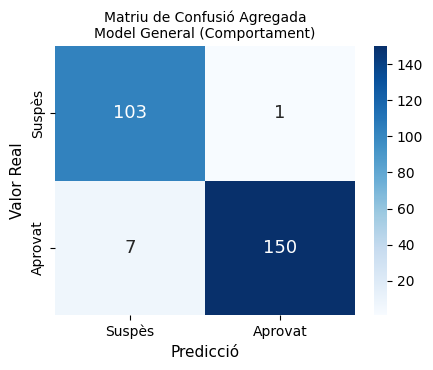

In [13]:
drop_meta_general = [c for c in id_est.columns if c in df_alt.columns] + ["aval"]
model_general, metrics_general = entrenar_model_lgbm(
    df_alt.drop(columns=drop_meta_general, errors='ignore'),
    nom="Model General (Comportament)",
    threshold=0.76)

## Models per Blocs Temporals

Per a cada bloc temporal (B1–B4) s'entrena un model independent amb les features disponibles fins a aquell instant del curs. El threshold de classificació s'ha ajustat manualment per a cada bloc:

- **Blocs B1–B3** (`threshold=0.76`): threshold elevat per reduir falsos positius en les primeres setmanes, quan les dades acadèmiques disponibles són escasses.
- **Bloc B4** (`threshold=0.5`): threshold estàndard quan es disposa de la informació completa del curs.



══════════════════════════════════════════════════════════════
  Bloc 1 (fins 11 abril)
══════════════════════════════════════════════════════════════
  Stratified 5-Fold CV  |  Threshold=0.76  |  scale_pos_weight=0.66

  Mètrica            Mitjana       Std
  ------------------------------------
  Accuracy            0.5500    0.0261
  Precision           0.8595    0.0836
  Recall              0.3123    0.0629
  F1                  0.4521    0.0602
  ROC-AUC             0.6536    0.0533


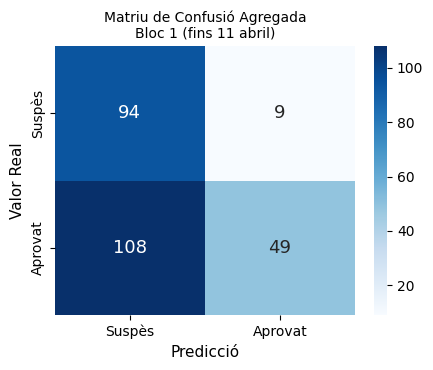


══════════════════════════════════════════════════════════════
  Bloc 2 (fins 12 maig)
══════════════════════════════════════════════════════════════
  Stratified 5-Fold CV  |  Threshold=0.76  |  scale_pos_weight=0.66

  Mètrica            Mitjana       Std
  ------------------------------------
  Accuracy            0.5097    0.0516
  Precision           0.7695    0.1411
  Recall              0.2984    0.1108
  F1                  0.4089    0.1287
  ROC-AUC             0.6992    0.0744


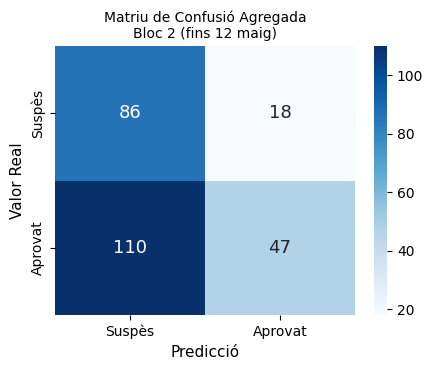


══════════════════════════════════════════════════════════════
  Bloc 3 (fins 27 maig)
══════════════════════════════════════════════════════════════
  Stratified 5-Fold CV  |  Threshold=0.76  |  scale_pos_weight=0.66

  Mètrica            Mitjana       Std
  ------------------------------------
  Accuracy            0.4866    0.0462
  Precision           0.5626    0.2816
  Recall              0.2546    0.1365
  F1                  0.3480    0.1800
  ROC-AUC             0.6608    0.1127


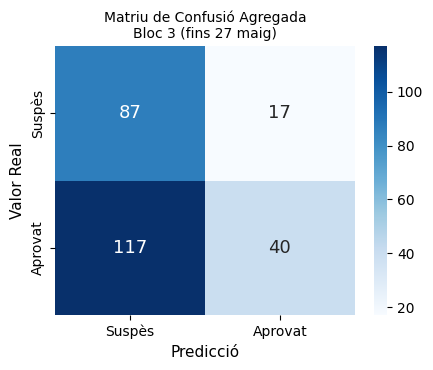


══════════════════════════════════════════════════════════════
  Bloc 4 (curs complet)
══════════════════════════════════════════════════════════════
  Stratified 5-Fold CV  |  Threshold=0.5  |  scale_pos_weight=0.66

  Mètrica            Mitjana       Std
  ------------------------------------
  Accuracy            0.5940    0.0389
  Precision           0.6789    0.0444
  Recall              0.6246    0.0324
  F1                  0.6496    0.0264
  ROC-AUC             0.6356    0.0440


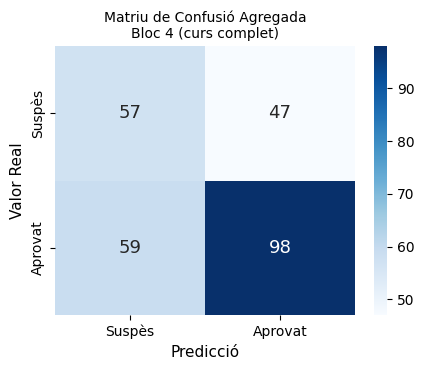

In [14]:
drop_meta = ["id", "grup", "semi", "lab", "aval"]
blocs = [
    (b1_df, "Bloc 1 (fins 11 abril)",  0.76),
    (b2_df, "Bloc 2 (fins 12 maig)",   0.76),
    (b3_df, "Bloc 3 (fins 27 maig)",   0.76),
    (b4_df, "Bloc 4 (curs complet)",   0.5),
]

models_blocs  = {}   # nom → millor model de cada bloc
metrics_blocs = {}   # nom → dict de mètriques mitjanes

for df_b, nom, thr in blocs:
    model, metrics = entrenar_model_lgbm(df_b, nom, drop_cols=drop_meta, threshold=thr)
    models_blocs[nom]  = model
    metrics_blocs[nom] = metrics


## Taula Comparativa de Resultats per Bloc Temporal



In [15]:
# Taula de mètriques per bloc
resultats_blocs = pd.DataFrame(metrics_blocs).T.round(4)
resultats_blocs.index.name = "Bloc"
print("\nComparativa de Models per Bloc Temporal")
print("=" * 70)
display(resultats_blocs)


Comparativa de Models per Bloc Temporal


,Accuracy,Precision,Recall,F1,ROC-AUC
Bloc,,,,,
Bloc 1 (fins 11 abril),0.5500,0.8595,0.3123,0.4521,0.6536
Bloc 2 (fins 12 maig),0.5097,0.7695,0.2984,0.4089,0.6992
Bloc 3 (fins 27 maig),0.4866,0.5626,0.2546,0.3480,0.6608
Bloc 4 (curs complet),0.5940,0.6789,0.6246,0.6496,0.6356


## Importància de Variables per Bloc



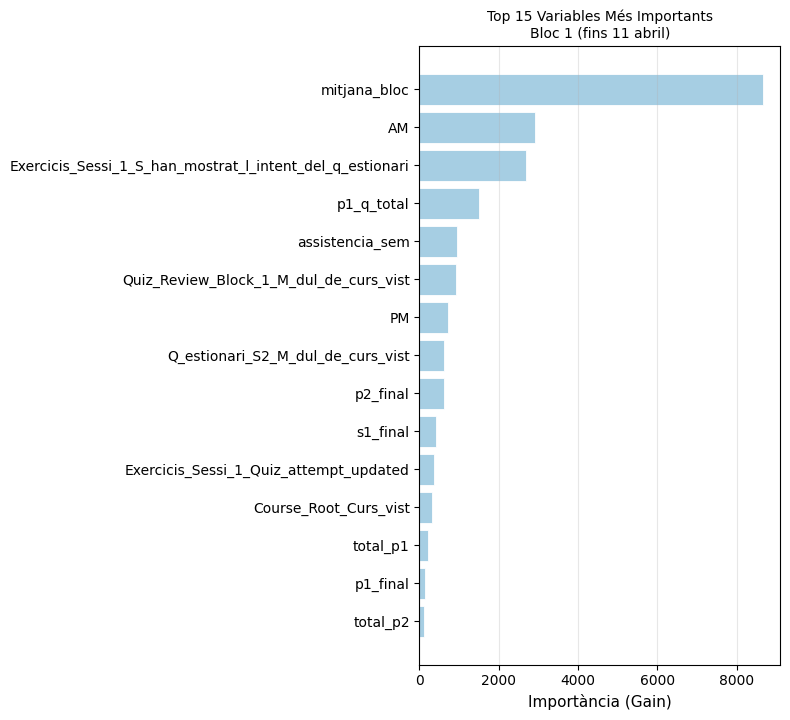

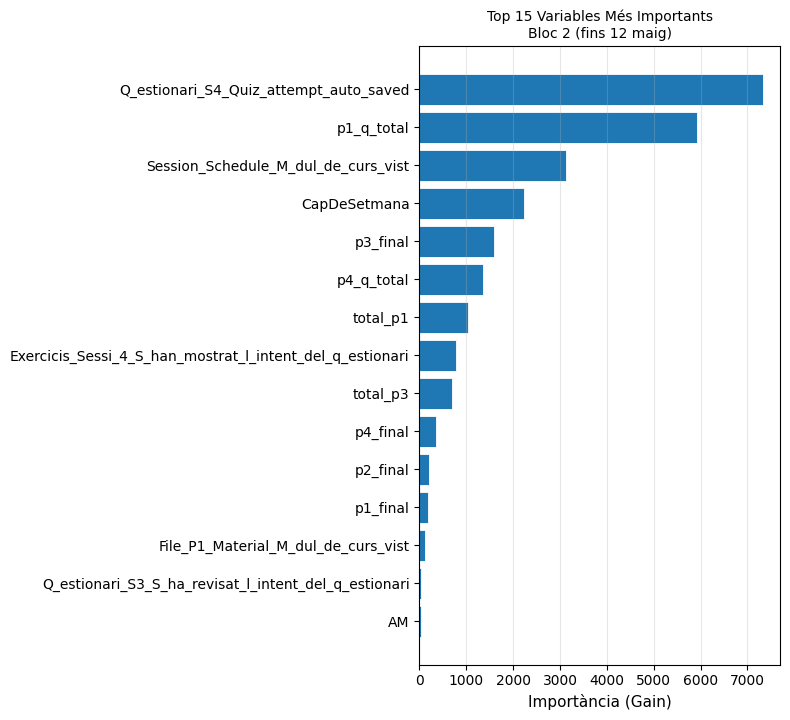

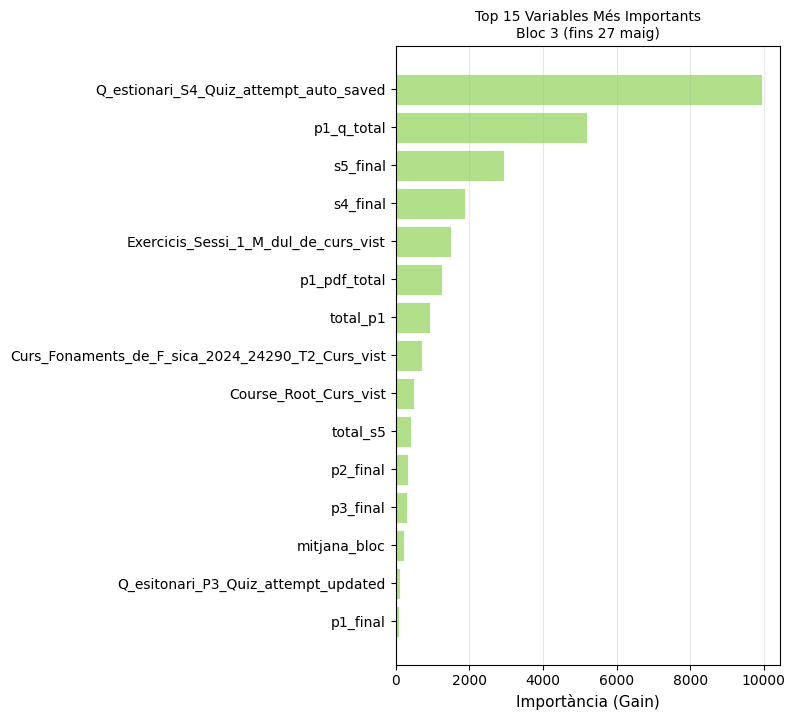

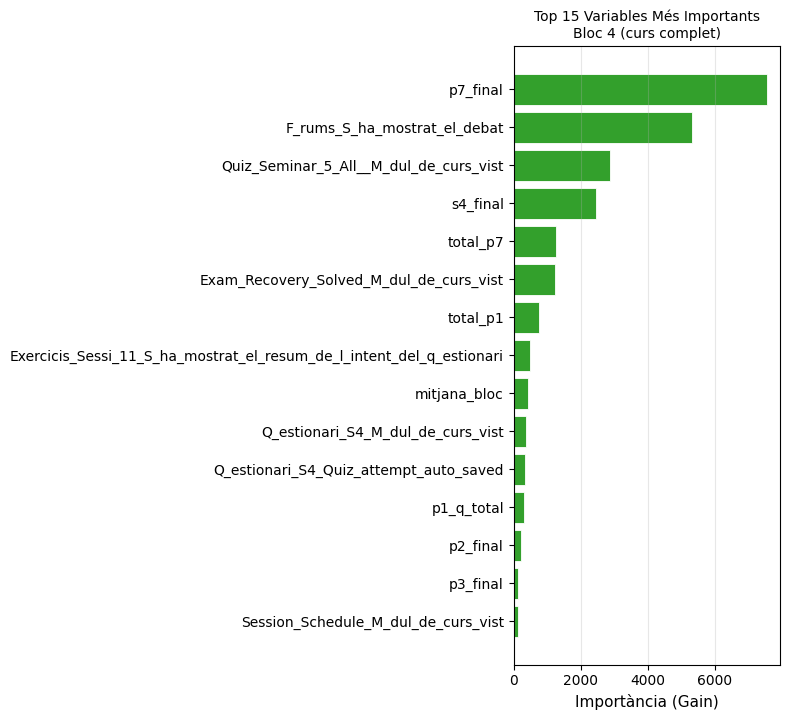

In [16]:
def plot_feature_importance(model, nom, top_n=15, color='#1f78b4'):
    """Visualitza les top_n variables més importants (gain) del model LightGBM."""
    importance = model.feature_importance(importance_type='gain')
    feat_names  = model.feature_name()
    fi_df = (pd.DataFrame({'feature': feat_names, 'importance': importance})
               .sort_values('importance', ascending=False)
               .head(top_n))

    fig, ax = plt.subplots(figsize=(8, top_n * 0.42 + 1))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
            color=color, edgecolor='white', linewidth=0.6)
    ax.set_xlabel('Importància (Gain)', fontsize=11)
    ax.set_title(f'Top {top_n} Variables Més Importants\n{nom}', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fi_df

# Colors per a cada bloc
colors_fi = ["#a6cee3", "#1f78b4", "#b2df8a", "#33a02c"]
for (df_b, nom, thr), color in zip(blocs, colors_fi):
    plot_feature_importance(models_blocs[nom], nom, top_n=15, color=color)


## Anàlisi SHAP — Interpretabilitat del Model


#### SHAP bàsic



/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


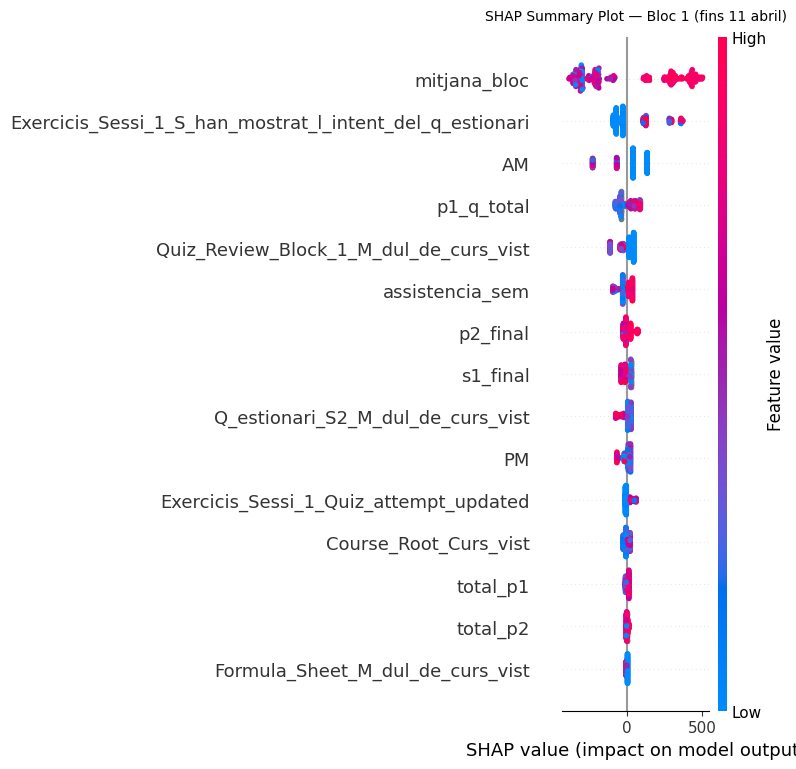

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


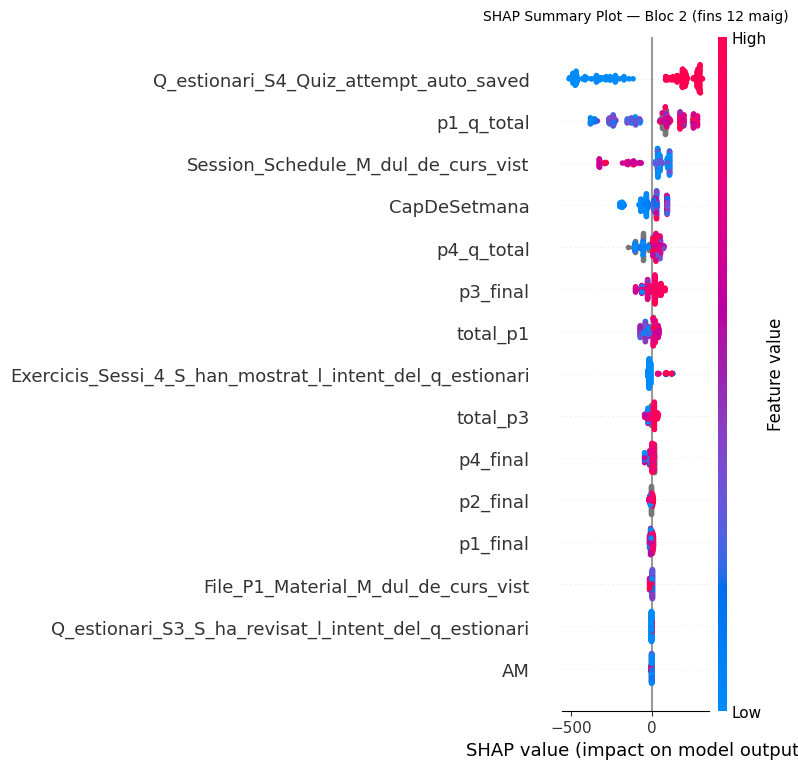

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


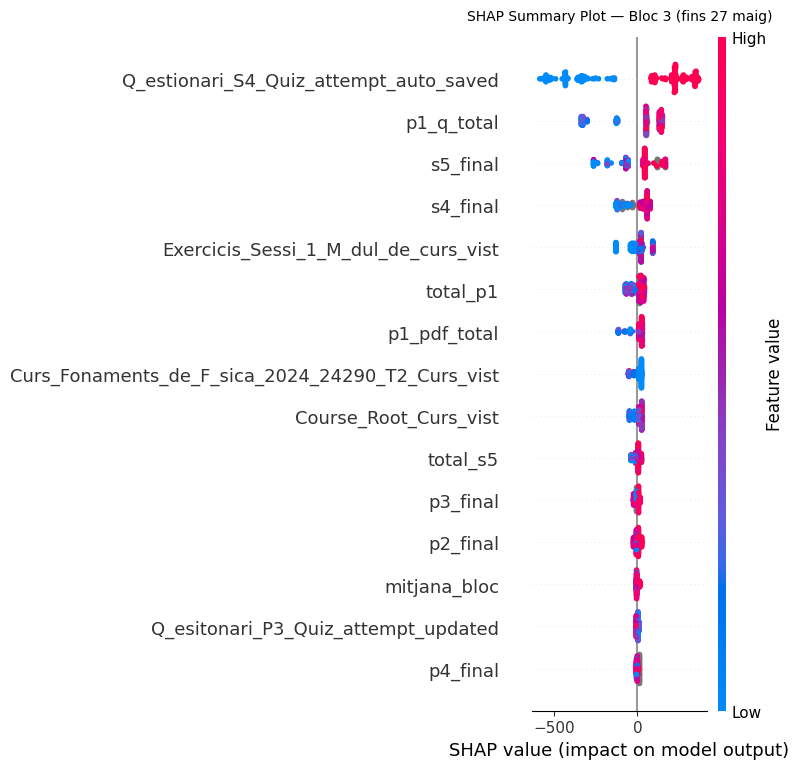

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


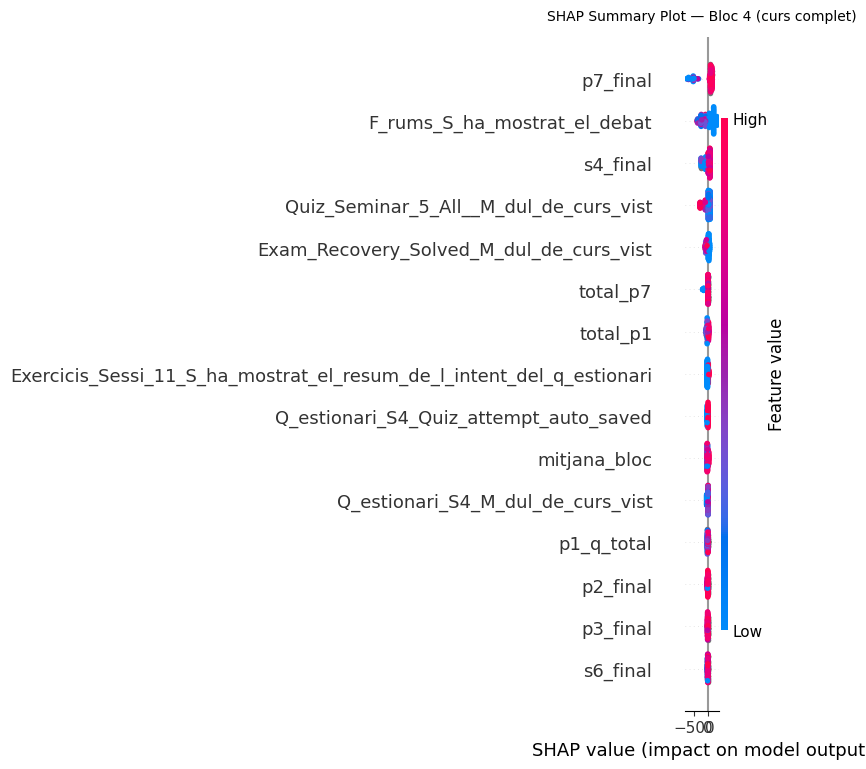

In [17]:

def analisi_shap(model, df_bloc, nom, drop_cols=None, max_display=15):
    """Genera el SHAP summary plot per al model del bloc especificat."""
    cols_drop = ["target"] + (drop_cols or [])
    X = df_bloc.drop(columns=[c for c in cols_drop if c in df_bloc.columns]).copy()
    X = X.reset_index(drop=True)
    X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # LightGBM binari retorna llista de 2 arrays → agafem la classe 1 (Aprovat)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(8, max_display * 0.42 + 1.5))
    shap.summary_plot(sv, X, max_display=max_display, show=False, plot_size=None)
    plt.title(f'SHAP Summary Plot — {nom}', fontsize=10, pad=12)
    plt.tight_layout()
    plt.show()

for df_b, nom, thr in blocs:
    analisi_shap(models_blocs[nom], df_b, nom, drop_cols=drop_meta)


#### SHAP avançat




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bloc 1 (fins 11 abril)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


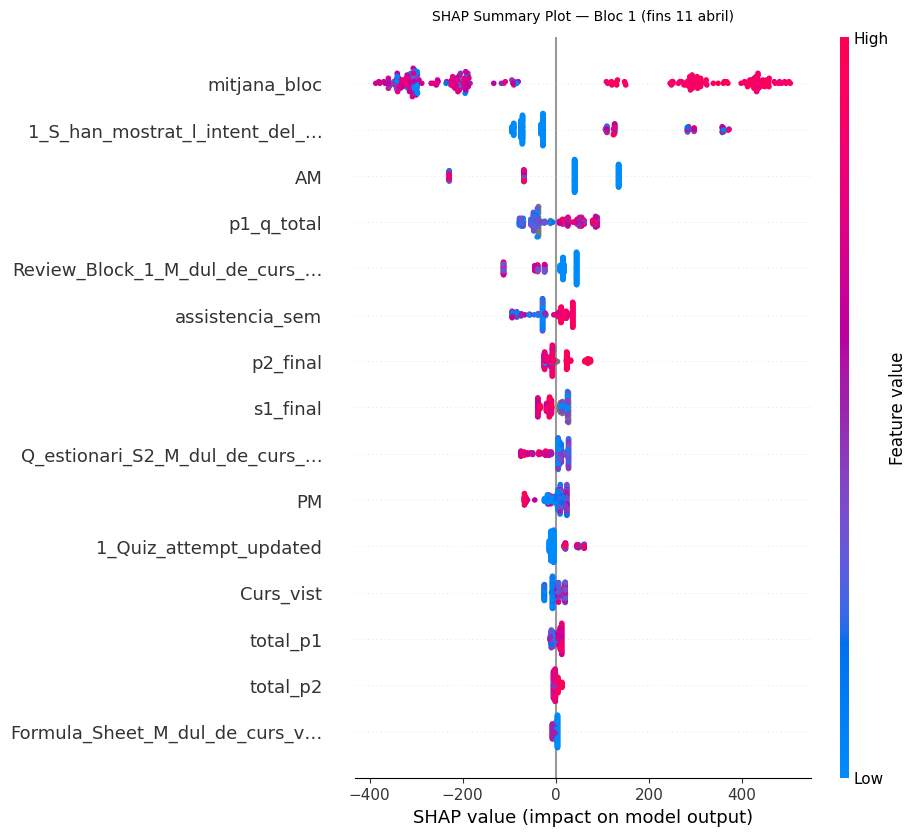

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


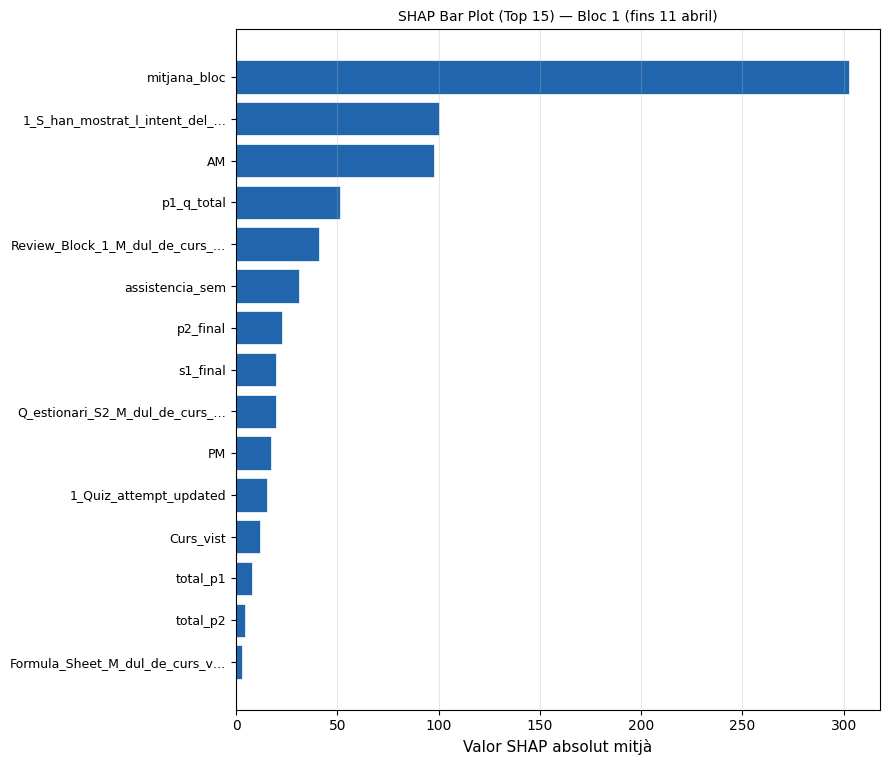

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


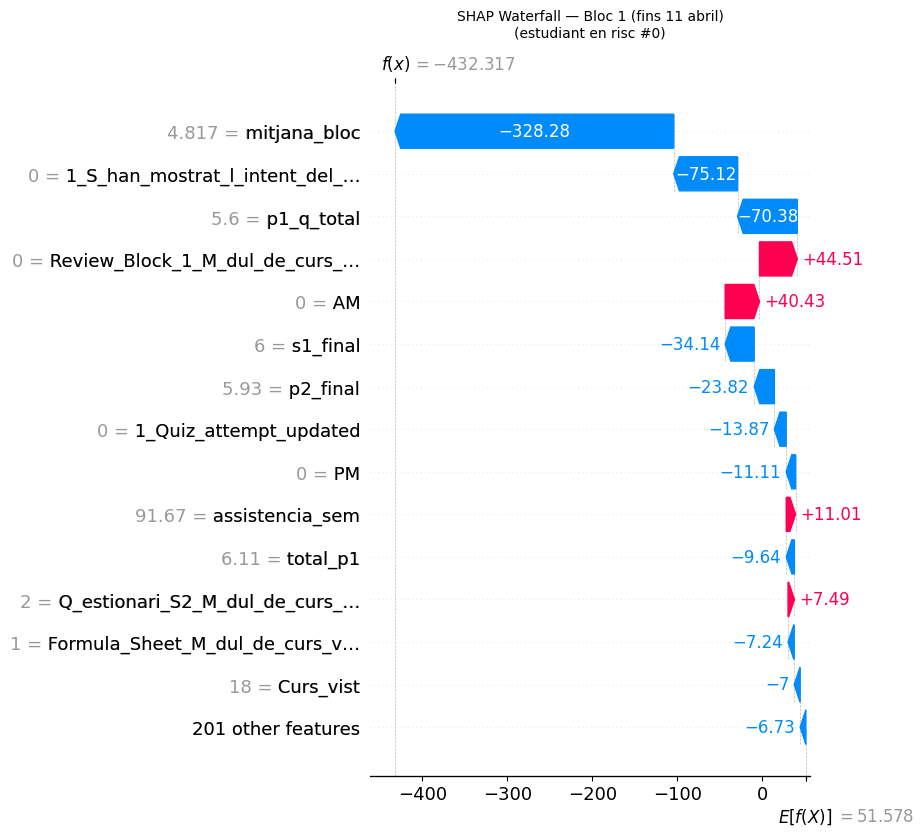

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


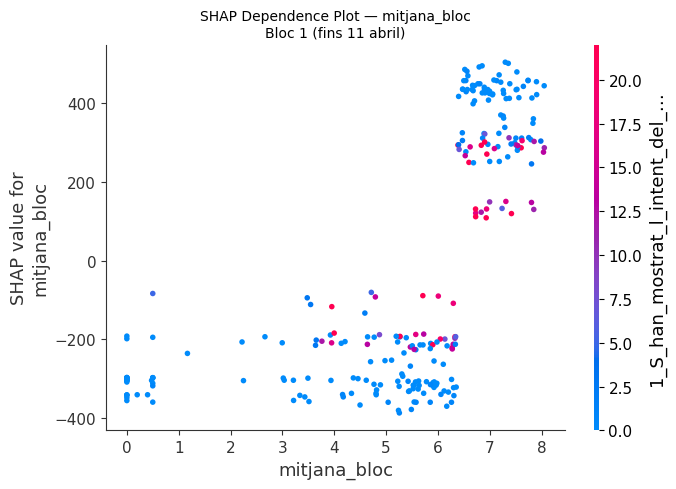


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bloc 2 (fins 12 maig)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


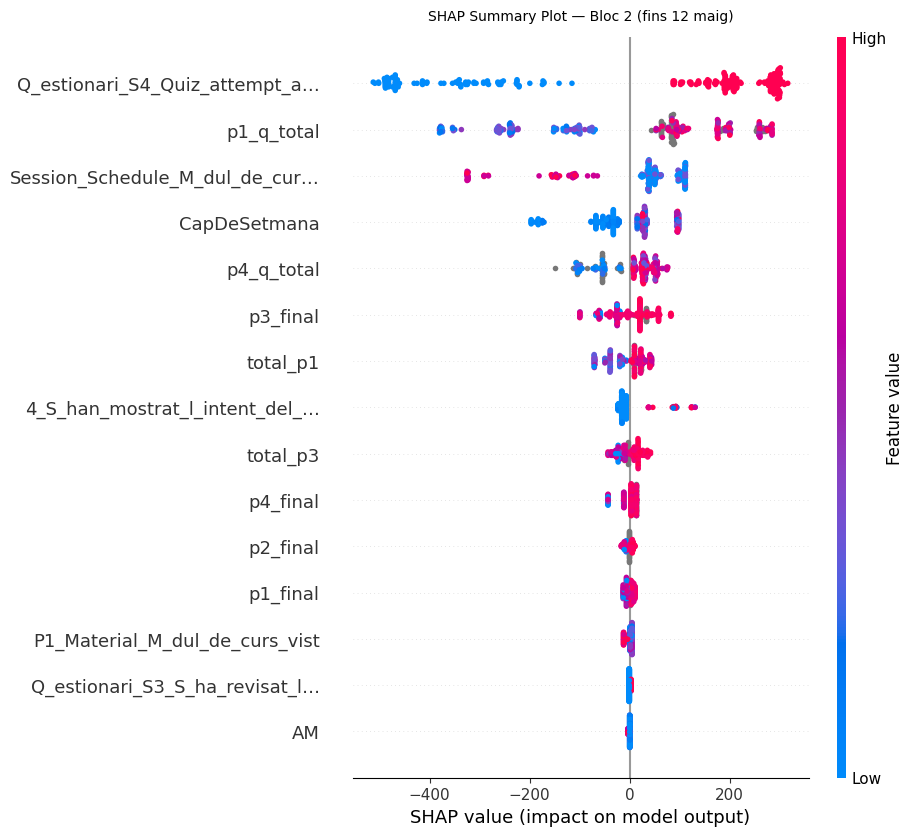

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


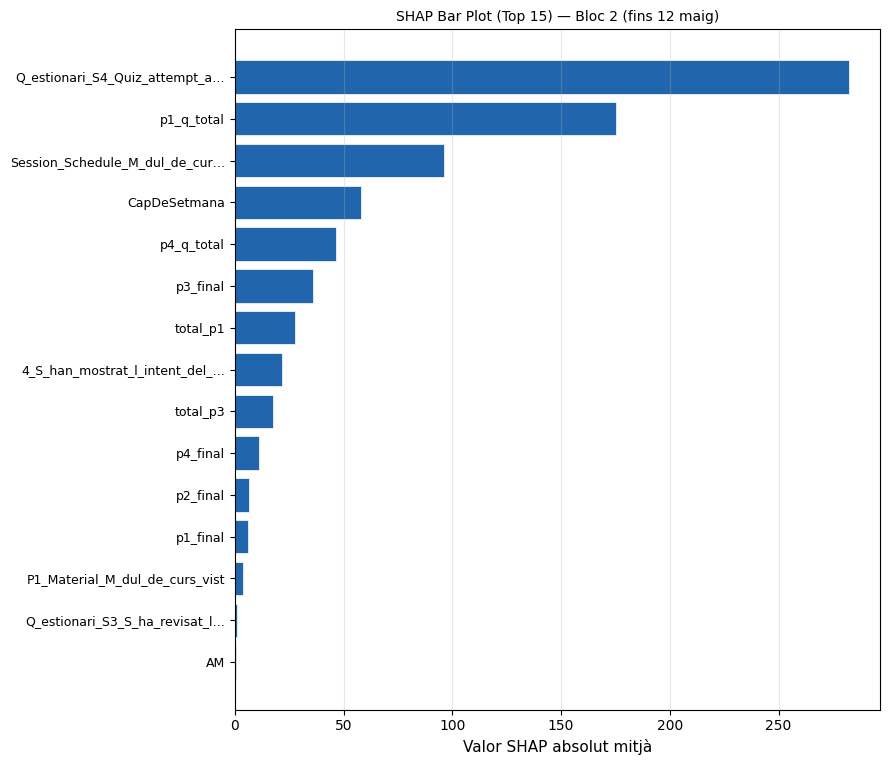

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


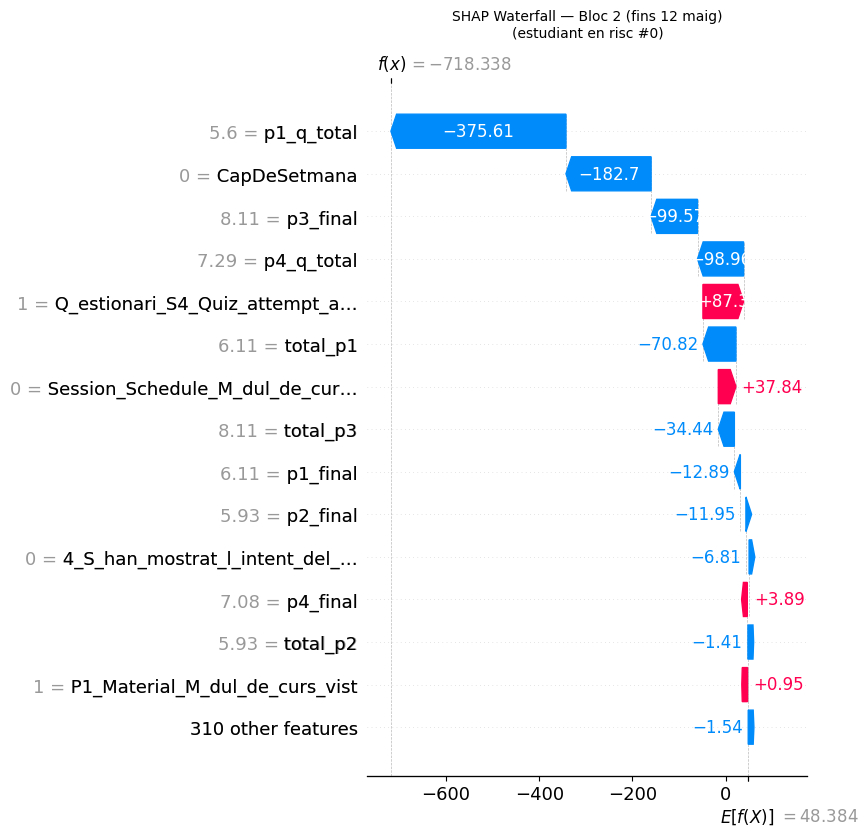

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


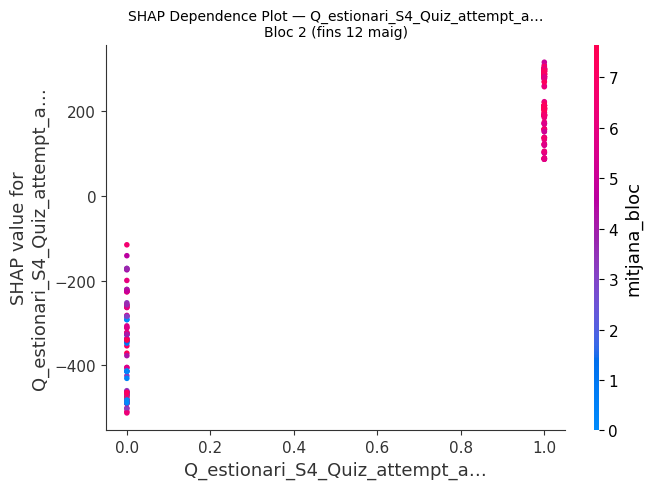


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bloc 3 (fins 27 maig)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


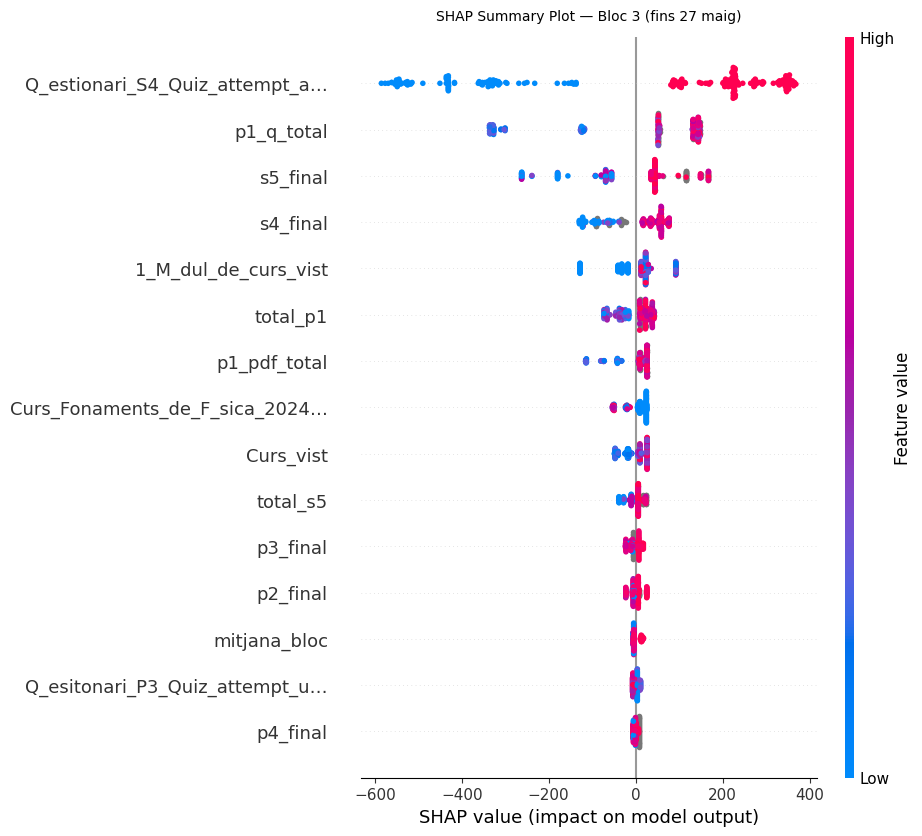

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


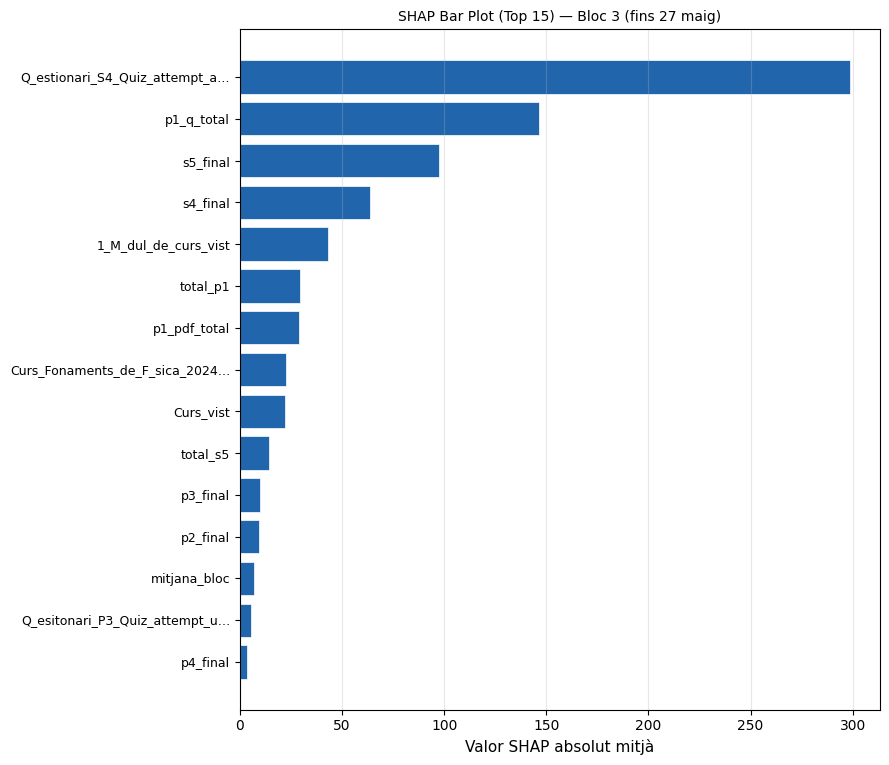

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


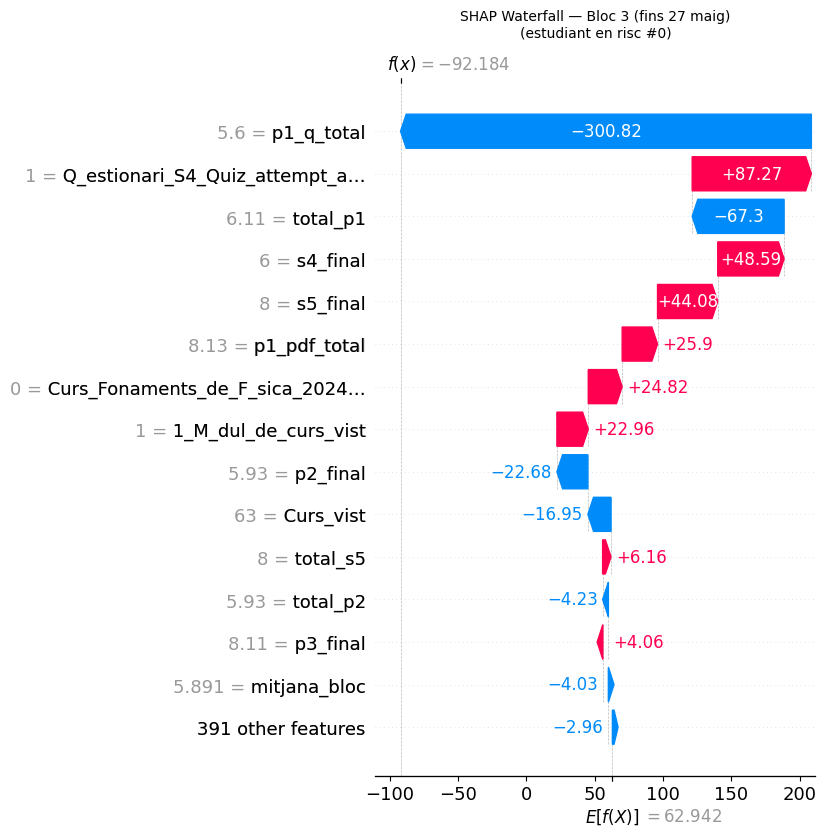

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


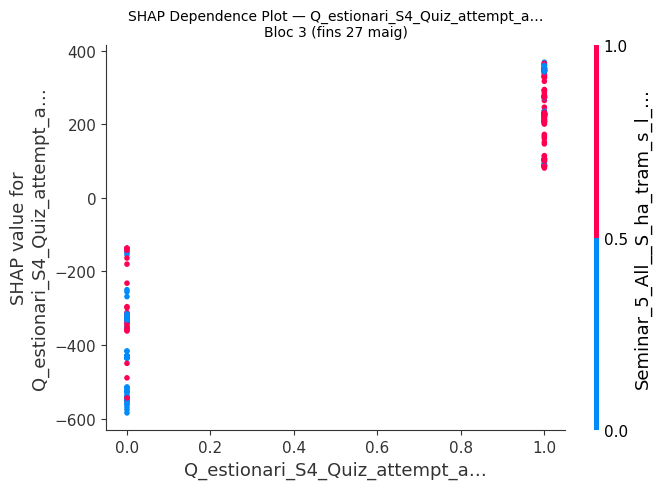


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bloc 4 (curs complet)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


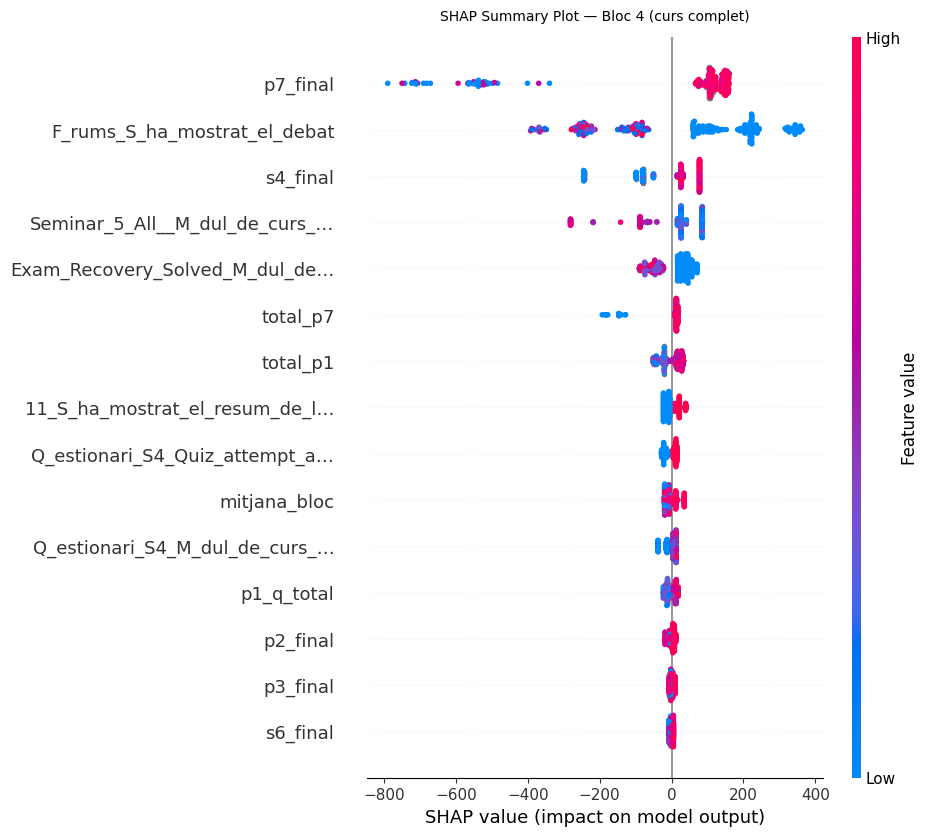

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


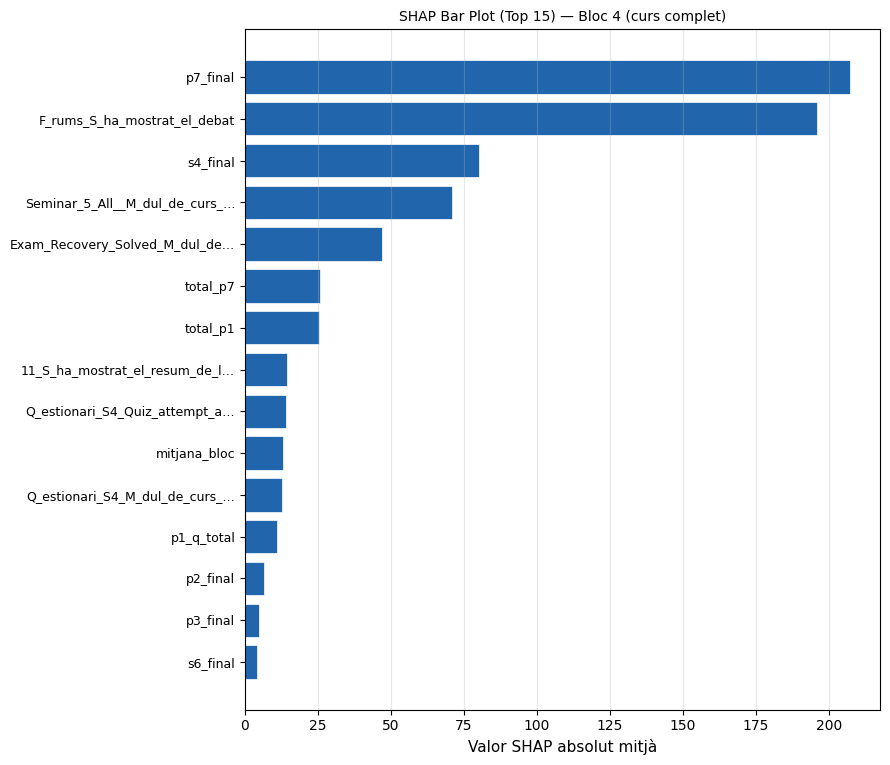

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


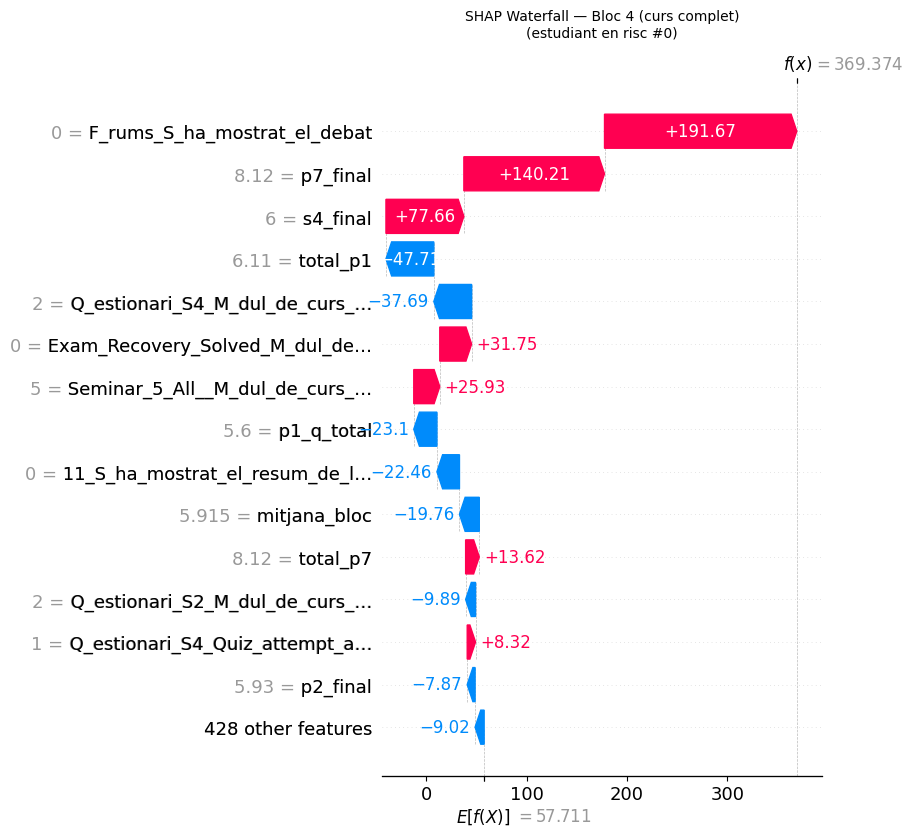

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


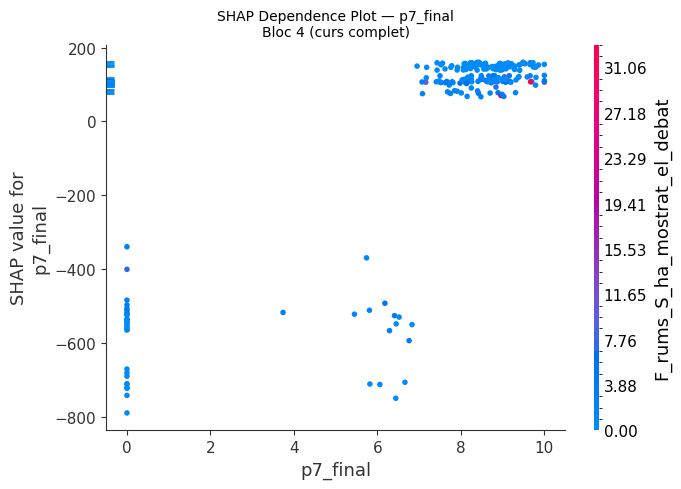

In [18]:
# Reducció dels noms de les variables, per a que es vegin bé els plots -> funció per a cada gràfic

def shorten_feature_names(X, max_len=30):
    """
    Trunca els noms de columna a max_len caràcters i elimina prefixos
    repetitius per netejar els eixos dels plots.
    """
    prefixes_to_strip = [
        "Qu_estionari_", "Qu_esitonari_", "Quiz__", "Quiz_",
        "Fitxer__", "Fitxer_", "File__", "File_",
        "Course_Root_", "Course_root_",
        "Exercicis_Sessi_", "Teoria_Sessi_",
    ]
    new_names = {}
    for col in X.columns:
        name = col
        for prefix in prefixes_to_strip:
            if name.startswith(prefix):
                name = name[len(prefix):]
                break
        if len(name) > max_len:
            name = name[:max_len - 1] + "…"
        new_names[col] = name

    # Desduplicació: si dos noms queden iguals, afegim un sufix numèric
    seen = {}
    deduped = {}
    for orig, short in new_names.items():
        if short in seen:
            seen[short] += 1
            deduped[orig] = f"{short}_{seen[short]}"
        else:
            seen[short] = 0
            deduped[orig] = short

    return X.rename(columns=deduped)


def prep_X(df_bloc, drop_cols=None, max_len=30):
    """Neteja el DataFrame: elimina columnes no-feature, normalitza noms i trunca."""
    cols_drop = ["target"] + (drop_cols or [])
    X = df_bloc.drop(columns=[c for c in cols_drop if c in df_bloc.columns]).copy()
    X = X.reset_index(drop=True)
    X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)
    X = shorten_feature_names(X, max_len=max_len)
    return X


def get_shap_values(model, X):
    """Retorna (explainer, shap_values classe 1) per a un model LightGBM binari."""
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X)
    sv_class1 = sv[1] if isinstance(sv, list) else sv
    return explainer, sv_class1


#  Summary Plot
def shap_summary(model, df_bloc, nom, drop_cols=None, max_display=15, max_len=30):
    """
    Beeswarm plot: cada punt és un estudiant.
    Eix X = valor SHAP | Color = valor de la feature (vermell alt, blau baix).
    Mostra direcció + magnitud + distribució alhora.
    """
    X = prep_X(df_bloc, drop_cols, max_len=max_len)
    _, sv = get_shap_values(model, X)

    fig_h = max(6, max_display * 0.45 + 1.5)
    plt.figure(figsize=(9, fig_h))
    shap.summary_plot(sv, X, max_display=max_display, show=False, plot_size=None)
    plt.title(f'SHAP Summary Plot — {nom}', fontsize=10, pad=12)
    plt.subplots_adjust(left=0.35)
    plt.show()


# Bar Plot

def shap_barplot(model, df_bloc, nom, drop_cols=None, top_n=15, max_len=30):
    """
    Barres horitzontals de la mitjana del valor absolut SHAP per feature.
    Complementa la importància (gain) del model amb una mètrica d'impacte real.
    """
    X = prep_X(df_bloc, drop_cols, max_len=max_len)
    _, sv = get_shap_values(model, X)

    mean_abs = np.abs(sv).mean(axis=0)
    fi_df = (pd.DataFrame({'feature': X.columns, 'mean_|SHAP|': mean_abs})
               .sort_values('mean_|SHAP|', ascending=False)
               .head(top_n))

    fig_h = max(5, top_n * 0.45 + 1)
    fig, ax = plt.subplots(figsize=(9, fig_h))
    ax.barh(fi_df['feature'][::-1], fi_df['mean_|SHAP|'][::-1],
            color='#2166ac', edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Valor SHAP absolut mitjà', fontsize=11)
    ax.set_title(f'SHAP Bar Plot (Top {top_n}) — {nom}', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fi_df


# Waterfall d'un estudiant concret

def shap_waterfall_estudiant(model, df_bloc, nom, drop_cols=None,
                              idx=0, label="estudiant", max_len=30):
    """
    Waterfall plot per a un estudiant individual (idx = fila de df_bloc).
    Mostra com cada feature empeny la predicció cap amunt (vermell) o cap avall (blau)
    respecte del valor base E[f(X)].
    Útil per explicar per què el model classifica un estudiant concret com a 'en risc'.
    """
    X = prep_X(df_bloc, drop_cols, max_len=max_len)
    explainer, _ = get_shap_values(model, X)

    explanation = explainer(X)
    if isinstance(explanation, list):
        explanation = explanation[1]

    plt.figure(figsize=(9, 6))
    shap.plots.waterfall(explanation[idx], max_display=15, show=False)
    plt.title(f'SHAP Waterfall — {nom}\n({label} #{idx})', fontsize=10, pad=12)
    plt.subplots_adjust(left=0.35)
    plt.show()


#Dependence Plot — relació entre una feature i el seu impacte SHAP

def shap_dependence(model, df_bloc, nom, drop_cols=None,
                    feature=None, interaction_feature='auto', max_len=30):
    """
    Scatter: valor real de la feature vs. el seu valor SHAP.
    Color = feature d'interacció (auto = la més correlacionada).
    Respon: 'A partir de quin llindar canvia la predicció del model?'
    """
    X = prep_X(df_bloc, drop_cols, max_len=max_len)
    _, sv = get_shap_values(model, X)

    if feature is None:
        idx_top = np.abs(sv).mean(axis=0).argmax()
        feature = X.columns[idx_top]

    fig, ax = plt.subplots(figsize=(7, 5))
    shap.dependence_plot(
        feature, sv, X,
        interaction_index=interaction_feature,
        ax=ax, show=False
    )
    ax.set_title(f'SHAP Dependence Plot — {feature}\n{nom}', fontsize=10)
    plt.tight_layout()
    plt.show()


# tots els plots per cada bloc temporal

drop_meta = ["id", "grup", "semi", "lab", "aval"]

for df_b, nom, thr in blocs:
    model = models_blocs[nom]
    print(f"\n{'━'*60}")
    print(f"  {nom}")
    print(f"{'━'*60}")
    shap_summary(model, df_b, nom, drop_cols=drop_meta)
    shap_barplot(model, df_b, nom, drop_cols=drop_meta, top_n=15)
    risc_idx = df_b[df_b['target'] == 0].index[0] if (df_b['target'] == 0).any() else 0
    shap_waterfall_estudiant(model, df_b, nom, drop_cols=drop_meta,
                              idx=risc_idx, label="estudiant en risc")
    shap_dependence(model, df_b, nom, drop_cols=drop_meta)

## Classificació d'Estudiants en Risc

Un cop entrenat el model de cada bloc, s'aplica sobre el conjunt complet d'estudiants per simular el funcionament real del **Sistema d'Alerta Primerenca**. S'identifiquen els estudiants classificats com a *en risc* (predicció = Suspès) en cada punt del curs, permetent així una intervenció precoç.

La funció `prediccions_bloc` aplica cada model sobre tots els estudiants del dataset corresponent i retorna:
- `prob_aprovat`: probabilitat estimada de superar l'assignatura.
- `en_risc`: 1 si el model classifica l'estudiant com a en risc (prob ≤ threshold).

El gràfic de barres mostra, per cada bloc temporal, quantes alertes s'han emès i quantes d'elles corresponen a un **Verdader Positiu** (estudiant que realment va suspendre).


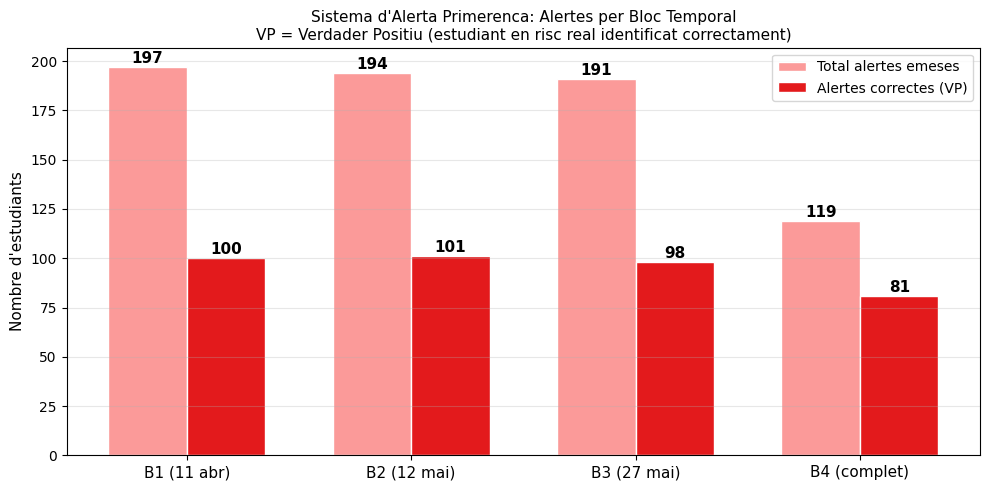

,Bloc,Total alertes,VP (risc real),Precisió alerta
0,Bloc 1 (fins 11 abril),197,100,50.8%
1,Bloc 2 (fins 12 maig),194,101,52.1%
2,Bloc 3 (fins 27 maig),191,98,51.3%
3,Bloc 4 (curs complet),119,81,68.1%


In [19]:
def prediccions_bloc(model, df_bloc, nom, drop_cols=None, threshold=0.5):
    """
    Aplica el model sobre tots els estudiants del bloc i retorna un DataFrame
    amb id, probabilitat d'aprovar i etiqueta de risc.
    """
    cols_drop = ["target"] + (drop_cols or [])
    X = df_bloc.drop(columns=[c for c in cols_drop if c in df_bloc.columns]).copy()
    X = X.reset_index(drop=True)
    ids = df_bloc["id"].reset_index(drop=True) if "id" in df_bloc.columns else pd.Series(range(len(X)), name="id")
    X_model = X.drop(columns=["id"], errors='ignore')
    X_model.columns = X_model.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

    prob_aprovat = model.predict(X_model)
    en_risc      = (prob_aprovat <= threshold).astype(int)

    return pd.DataFrame({
        "id":          ids,
        "prob_aprovat": prob_aprovat.round(3),
        "en_risc":      en_risc,
        "target_real":  df_bloc["target"].reset_index(drop=True)
    })

#  Resum d'alertes per bloc
fig, ax = plt.subplots(figsize=(10, 5))
colors_risc = ["#a6cee3", "#1f78b4", "#b2df8a", "#33a02c"]
x = np.arange(len(blocs))
width = 0.35

total_en_risc     = []
verdaders_positius = []

for df_b, nom, thr in blocs:
    preds = prediccions_bloc(models_blocs[nom], df_b, nom, drop_cols=drop_meta, threshold=thr)
    n_risc = preds["en_risc"].sum()
    vp     = ((preds["en_risc"] == 1) & (preds["target_real"] == 0)).sum()
    total_en_risc.append(n_risc)
    verdaders_positius.append(vp)

bars1 = ax.bar(x - width/2, total_en_risc, width, label='Total alertes emeses',
               color='#fb9a99', edgecolor='white')
bars2 = ax.bar(x + width/2, verdaders_positius, width, label='Alertes correctes (VP)',
               color='#e31a1c', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(["B1 (11 abr)", "B2 (12 mai)", "B3 (27 mai)", "B4 (complet)"], fontsize=11)
ax.set_ylabel("Nombre d'estudiants", fontsize=11)
ax.set_title("Sistema d'Alerta Primerenca: Alertes per Bloc Temporal\n"
             "VP = Verdader Positiu (estudiant en risc real identificat correctament)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Taula resum
resum_ews = pd.DataFrame({
    "Bloc":             [nom for _, nom, _ in blocs],
    "Total alertes":    total_en_risc,
    "VP (risc real)":   verdaders_positius,
    "Precisió alerta":  [f"{vp/tot:.1%}" if tot > 0 else "—"
                         for vp, tot in zip(verdaders_positius, total_en_risc)]
})
display(resum_ews)


# Optimització d'Hiperparàmetres amb Optuna

Per trobar el model amb millor rendiment, s'aplica el procés correcte en tres passos:

1. **Hold-out test set (20%)**: apartat des del principi, no es toca fins al final.
2. **Cerca d'hiperparàmetres (Optuna + CV)**: sobre el 80% restant, Optuna utilitza l'algorisme TPE (*Tree-structured Parzen Estimator*) per trobar els hiperparàmetres que maximitzen el ROC-AUC en validació creuada estratificada. A diferència de Grid Search, aprèn de cada prova anterior.
3. **Avaluació final**: es reentrena amb els millors hiperparàmetres sobre tot el train set i s'avalua **una única vegada** sobre el test set hold-out.

A més, el threshold de classificació s'optimitza automàticament sobre les prediccions del train set per maximitzar el F1-score dels suspesos (classe en risc).

### Funció d'optimització `optuna_lgbm`

El procés segueix tres passos per garantir una avaluació sense **data leakage**:

1. **Hold-out test set (20%)**: apartat des del principi, mai visible durant l'optimització.
2. **Optuna + CV estratificada**: sobre el 80% restant, l'algorisme TPE (*Tree-structured Parzen Estimator*) explora l'espai d'hiperparàmetres en 60 trials, maximitzant el ROC-AUC en validació creuada.
3. **Threshold òptim sobre el train set**: es tria el threshold que maximitza el F1 dels suspesos (classe 0), sense tocar el test set.
4. **Avaluació final**: el model es reentrena amb els millors hiperparàmetres sobre tot el train set i s'avalua **una única vegada** sobre el test hold-out.

S'optimitzen: `boosting_type`, `num_leaves`, `learning_rate`, `n_estimators`, `bagging_fraction`, `feature_fraction`, `min_child_samples`, `reg_alpha` i `reg_lambda`.


In [20]:

optuna.logging.set_verbosity(optuna.logging.WARNING) # Només mostra els Warnings, sense info logs.

def optuna_lgbm(df_bloc, nom, drop_cols=None, n_trials=60, test_size=0.2, n_splits=5):
    """
    Cerca els millors hiperparàmetres de LightGBM amb Optuna (TPE) i avalua el model
    sobre un hold-out test set que no s'ha tocat durant l'optimització.

    Retorna: (millor_model, mètriques_test, study, threshold_òptim)
    """
    cols_drop = ["target"] + (drop_cols or [])
    X = df_bloc.drop(columns=[c for c in cols_drop if c in df_bloc.columns]).copy()
    y = df_bloc["target"].reset_index(drop=True)
    X = X.reset_index(drop=True)
    X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

    # ── 1. Hold-out test set ───────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    X_train = X_train.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)

    n_neg = int((y_train == 0).sum())
    n_pos = int((y_train == 1).sum())
    spw   = n_neg / n_pos  # scale_pos_weight

    #  Funció objectiu
    def objective(trial):
        boosting = trial.suggest_categorical("boosting_type", ["gbdt", "rf", "dart"])
        params = {
            "objective":         "binary",
            "metric":            "binary_logloss",
            "boosting_type":     boosting,
            "num_leaves":        trial.suggest_int("num_leaves", 4, 63),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "n_estimators":      trial.suggest_int("n_estimators", 100, 800),
            "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.5, 1.0),
            "feature_fraction":  trial.suggest_float("feature_fraction", 0.4, 1.0),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
            "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 5.0),
            "reg_lambda":        trial.suggest_float("reg_lambda", 0.0, 5.0),
            "scale_pos_weight":  spw,
            "force_row_wise":    True,
            "verbose":           -1,
        }
        if boosting == "rf":
            params["bagging_freq"] = 1

        skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        aucs    = []
        n_est   = params.pop("n_estimators")
        for tr_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            bst = lgb.train(params, lgb.Dataset(X_tr, label=y_tr),
                            num_boost_round=n_est,
                            callbacks=[lgb.log_evaluation(period=-1)])
            aucs.append(roc_auc_score(y_val, bst.predict(X_val)))
        return np.mean(aucs)

    # execució
    print(f"\n  Optimitzant {nom} ({n_trials} trials)...")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_p = study.best_params.copy()
    boosting_best = best_p.get("boosting_type", "gbdt")
    n_est_best    = best_p.pop("n_estimators")
    final_params  = {
        **best_p,
        "objective":        "binary",
        "metric":           "binary_logloss",
        "scale_pos_weight": spw,
        "force_row_wise":   True,
        "verbose":          -1,
    }
    if boosting_best == "rf":
        final_params["bagging_freq"] = 1

    # Reentrenament
    best_model = lgb.train(final_params,
                           lgb.Dataset(X_train, label=y_train),
                           num_boost_round=n_est_best,
                           callbacks=[lgb.log_evaluation(period=-1)])

    # Threshold òptim (sobre train, per evitar data leakage)
    y_train_prob = best_model.predict(X_train)
    thresholds   = np.linspace(0.1, 0.9, 81)
    # Optimitzem recall dels suspesos
    f1_susp = [f1_score(y_train, (y_train_prob > t).astype(int),
                        pos_label=0, zero_division=0) for t in thresholds]
    best_thr = float(thresholds[np.argmax(f1_susp)])

    # Avaluació final sobre el hold-out test set
    y_test_prob = best_model.predict(X_test)
    y_test_pred = (y_test_prob > best_thr).astype(int)

    metrics = {
        "Accuracy":  round(accuracy_score(y_test, y_test_pred), 4),
        "Precision": round(precision_score(y_test, y_test_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_test_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_test, y_test_pred, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_test_prob), 4),
        "Threshold": round(best_thr, 2),
    }


    print(f"\n{'═'*62}")
    print(f"  {nom}")
    print(f"{'═'*62}")
    print(f"  Millors hiperparàmetres ({n_trials} trials, ROC-AUC = {study.best_value:.4f} en CV):")
    for k, v in study.best_params.items():
        print(f"    {k:<22}: {v}")
    print(f"\n  Threshold òptim (F1 suspesos sobre train): {best_thr:.2f}")
    print(f"\n  Resultats sobre el test set hold-out (20%):")
    print(f"  {'Mètrica':<15} {'Valor':>8}")
    print(f"  {'-'*25}")
    for k, v in metrics.items():
        print(f"  {k:<15} {v:>8}")
    print()
    print(classification_report(y_test, y_test_pred,
                                 target_names=["Suspès", "Aprovat"]))

    # Conf. Matrix
    cm  = confusion_matrix(y_test, y_test_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Suspès', 'Aprovat'],
                yticklabels=['Suspès', 'Aprovat'],
                annot_kws={"size": 13})
    axes[0].set_xlabel('Predicció', fontsize=11)
    axes[0].set_ylabel('Valor Real', fontsize=11)
    axes[0].set_title(f'Matriu de Confusió (Test Set)\n{nom}', fontsize=10)

    # Info
    trials_df = study.trials_dataframe()
    axes[1].plot(trials_df.index, trials_df["value"], alpha=0.4, color='#1f78b4', label='Trial')
    axes[1].plot(trials_df.index,
                 trials_df["value"].cummax(), color='tomato', linewidth=2, label='Millor acumulat')
    axes[1].set_xlabel('Trial', fontsize=11)
    axes[1].set_ylabel('ROC-AUC (CV)', fontsize=11)
    axes[1].set_title(f'Historial d\'Optimització Optuna\n{nom}', fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return best_model, metrics, study, best_thr


## Execució de l'Optimització per Cada Bloc




  Optimitzant Bloc 1 (fins 11 abril) (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════
  Bloc 1 (fins 11 abril)
══════════════════════════════════════════════════════════════
  Millors hiperparàmetres (60 trials, ROC-AUC = 0.7171 en CV):
    boosting_type         : rf
    num_leaves            : 17
    learning_rate         : 0.018652150038493187
    n_estimators          : 711
    bagging_fraction      : 0.9336141669845374
    feature_fraction      : 0.9033742732851767
    min_child_samples     : 19
    reg_alpha             : 0.9863414847737568
    reg_lambda            : 4.174664450865224

  Threshold òptim (F1 suspesos sobre train): 0.58

  Resultats sobre el test set hold-out (20%):
  Mètrica            Valor
  -------------------------
  Accuracy          0.5192
  Precision         0.6667
  Recall            0.3871
  F1                0.4898
  ROC-AUC           0.5691
  Threshold           0.58

              precision    recall  f1-score   support

      Suspès       0.44      0.71      0.55        21

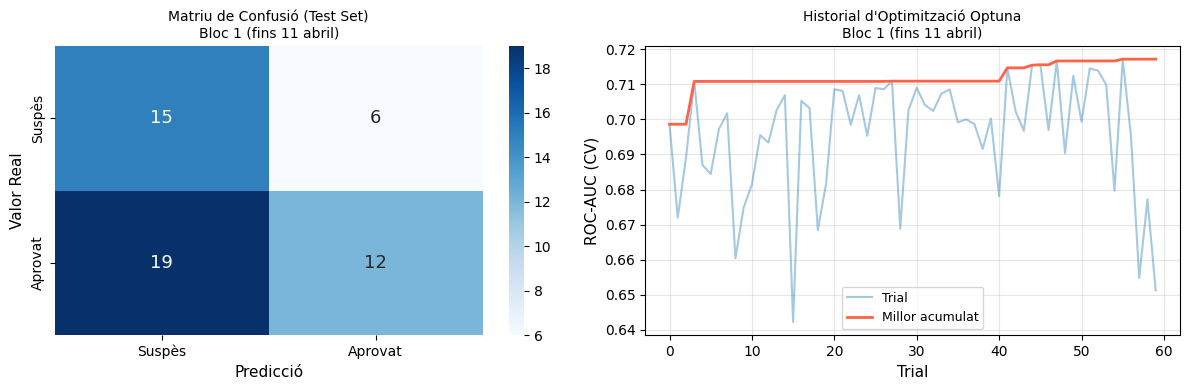


  Optimitzant Bloc 2 (fins 12 maig) (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════
  Bloc 2 (fins 12 maig)
══════════════════════════════════════════════════════════════
  Millors hiperparàmetres (60 trials, ROC-AUC = 0.7887 en CV):
    boosting_type         : gbdt
    num_leaves            : 13
    learning_rate         : 0.04271889137481741
    n_estimators          : 606
    bagging_fraction      : 0.9572426655720625
    feature_fraction      : 0.6122682345938106
    min_child_samples     : 7
    reg_alpha             : 0.0009736594238925547
    reg_lambda            : 3.1122263503835197

  Threshold òptim (F1 suspesos sobre train): 0.10

  Resultats sobre el test set hold-out (20%):
  Mètrica            Valor
  -------------------------
  Accuracy          0.6038
  Precision         0.6122
  Recall            0.9375
  F1                0.7407
  ROC-AUC           0.5863
  Threshold            0.1

              precision    recall  f1-score   support

      Suspès       0.50      0.10      0.16       

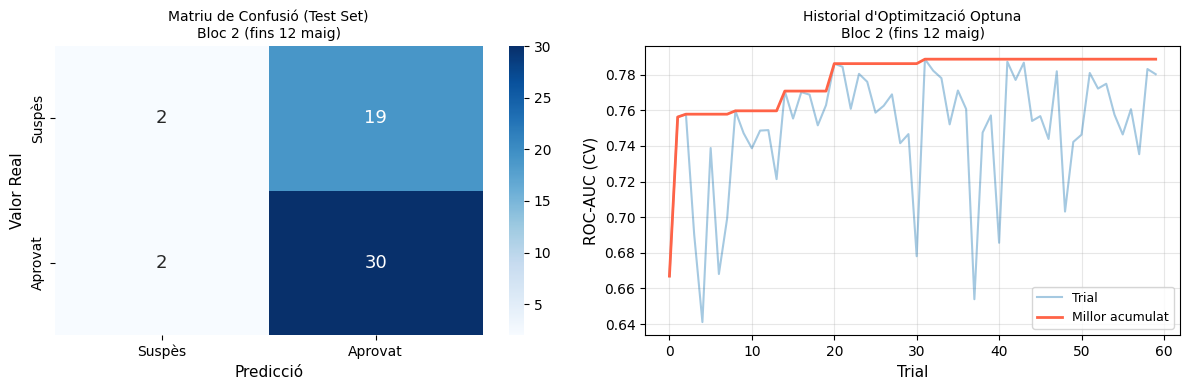


  Optimitzant Bloc 3 (fins 27 maig) (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════
  Bloc 3 (fins 27 maig)
══════════════════════════════════════════════════════════════
  Millors hiperparàmetres (60 trials, ROC-AUC = 0.7574 en CV):
    boosting_type         : gbdt
    num_leaves            : 19
    learning_rate         : 0.02923901265933081
    n_estimators          : 396
    bagging_fraction      : 0.7179653186323941
    feature_fraction      : 0.5402544284673607
    min_child_samples     : 14
    reg_alpha             : 0.9533690291263447
    reg_lambda            : 1.705071097263021

  Threshold òptim (F1 suspesos sobre train): 0.28

  Resultats sobre el test set hold-out (20%):
  Mètrica            Valor
  -------------------------
  Accuracy          0.6226
  Precision          0.625
  Recall            0.9375
  F1                  0.75
  ROC-AUC            0.625
  Threshold           0.28

              precision    recall  f1-score   support

      Suspès       0.60      0.14      0.23        21

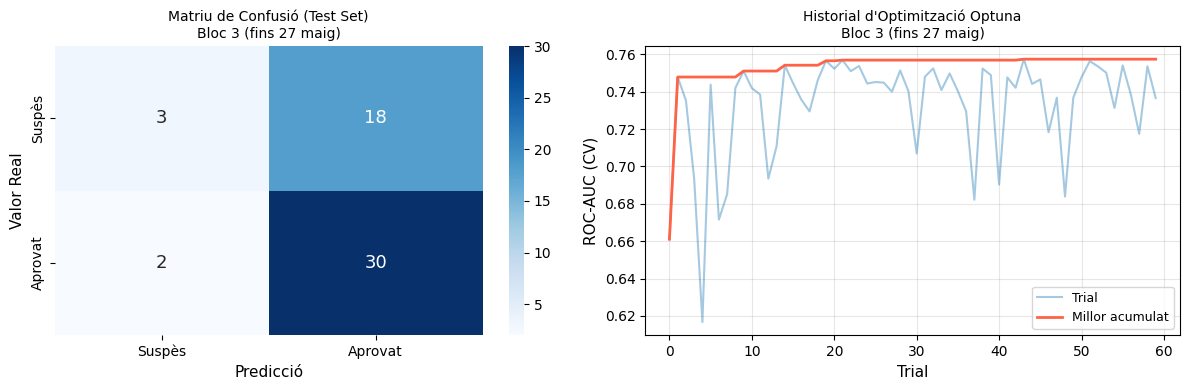


  Optimitzant Bloc 4 (curs complet) (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════
  Bloc 4 (curs complet)
══════════════════════════════════════════════════════════════
  Millors hiperparàmetres (60 trials, ROC-AUC = 0.7936 en CV):
    boosting_type         : dart
    num_leaves            : 50
    learning_rate         : 0.15092971636254945
    n_estimators          : 726
    bagging_fraction      : 0.6877825317361238
    feature_fraction      : 0.696338504139723
    min_child_samples     : 47
    reg_alpha             : 2.6434507021964957
    reg_lambda            : 4.7721503388120485

  Threshold òptim (F1 suspesos sobre train): 0.51

  Resultats sobre el test set hold-out (20%):
  Mètrica            Valor
  -------------------------
  Accuracy          0.6226
  Precision         0.6765
  Recall            0.7188
  F1                 0.697
  ROC-AUC           0.6533
  Threshold           0.51

              precision    recall  f1-score   support

      Suspès       0.53      0.48      0.50        21

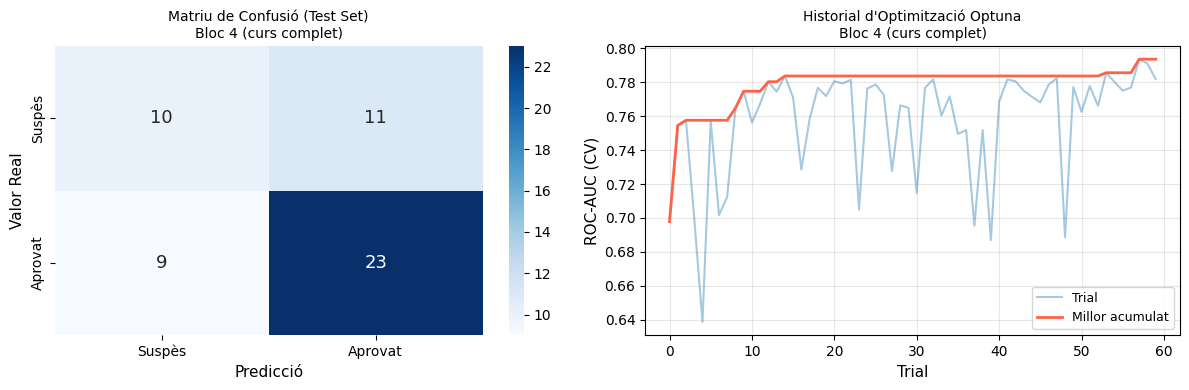

In [21]:
models_optuna  = {}   # millor model Optuna
metrics_optuna = {}   #  mètriques test
studies_optuna = {}   # study d'Optuna
thresholds_optuna = {}

for df_b, nom, _ in blocs:
    model, metrics, study, thr = optuna_lgbm(
        df_b, nom, drop_cols=drop_meta, n_trials=60
    )
    models_optuna[nom]     = model
    metrics_optuna[nom]    = metrics
    studies_optuna[nom]    = study
    thresholds_optuna[nom] = thr


## Comparativa: Baseline vs. Optuna

Es comparen les mètriques del model baseline (hiperparàmetres fixos, CV) amb les del model optimitzat amb Optuna (hold-out test set).

La comparativa mostra la millora obtinguda per cada bloc en F1-Score i ROC-AUC. La columna **Threshold Optuna** indica el punt de tall òptim trobat automàticament per a cada model.



Comparativa Baseline vs. Optuna per Bloc Temporal


,F1 Baseline,F1 Optuna,AUC Baseline,AUC Optuna,Recall Baseline,Recall Optuna,Threshold Optuna
Bloc,,,,,,,
Bloc 1 (fins 11 abril),0.4521,0.4898,0.6536,0.5691,0.3123,0.3871,0.58
Bloc 2 (fins 12 maig),0.4089,0.7407,0.6992,0.5863,0.2984,0.9375,0.10
Bloc 3 (fins 27 maig),0.3480,0.7500,0.6608,0.6250,0.2546,0.9375,0.28
Bloc 4 (curs complet),0.6496,0.6970,0.6356,0.6533,0.6246,0.7188,0.51


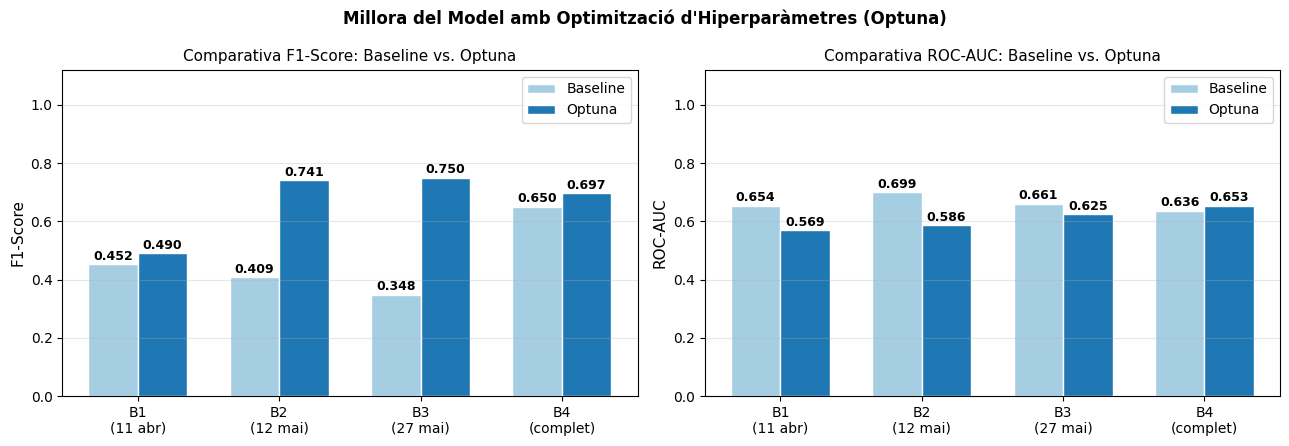

In [22]:
#Taula comparativa
rows = []
for _, nom, _ in blocs:
    m_base  = metrics_blocs[nom]
    m_optuna = metrics_optuna[nom]
    rows.append({
        "Bloc":             nom,
        "F1 Baseline":      m_base["F1"],
        "F1 Optuna":        m_optuna["F1"],
        "AUC Baseline":     m_base["ROC-AUC"],
        "AUC Optuna":       m_optuna["ROC-AUC"],
        "Recall Baseline":  m_base["Recall"],
        "Recall Optuna":    m_optuna["Recall"],
        "Threshold Optuna": m_optuna["Threshold"],
    })

comp_df = pd.DataFrame(rows).set_index("Bloc")
print("\nComparativa Baseline vs. Optuna per Bloc Temporal")
print("=" * 70)
display(comp_df)

#  Comparació F1 i ROC-AUC
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
noms_curts = ["B1\n(11 abr)", "B2\n(12 mai)", "B3\n(27 mai)", "B4\n(complet)"]
x = np.arange(len(blocs))
w = 0.35

for ax, met_base, met_opt, ylabel in zip(
    axes,
    ["F1 Baseline", "AUC Baseline"],
    ["F1 Optuna",   "AUC Optuna"],
    ["F1-Score",    "ROC-AUC"]
):
    vals_b = comp_df[met_base].values
    vals_o = comp_df[met_opt].values
    bars_b = ax.bar(x - w/2, vals_b, w, label='Baseline', color='#a6cee3', edgecolor='white')
    bars_o = ax.bar(x + w/2, vals_o, w, label='Optuna',   color='#1f78b4', edgecolor='white')
    for bar in list(bars_b) + list(bars_o):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(noms_curts, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"Comparativa {ylabel}: Baseline vs. Optuna", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Millora del Model amb Optimització d'Hiperparàmetres (Optuna)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


#### Gràfic comparatiu d'alertes emeses (Baseline vs. Optuna)

/tmp/ipykernel_818/3876643515.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlGnBu')


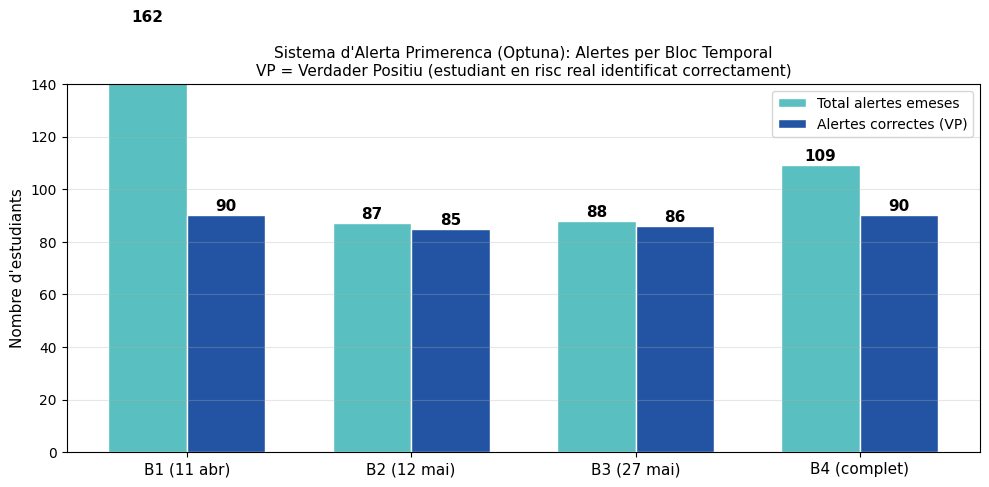

,Bloc,Total alertes,VP (risc real),Precisió alerta
0,Bloc 1 (fins 11 abril),162,90,55.6%
1,Bloc 2 (fins 12 maig),87,85,97.7%
2,Bloc 3 (fins 27 maig),88,86,97.7%
3,Bloc 4 (curs complet),109,90,82.6%


In [23]:

cmap = cm.get_cmap('YlGnBu')
col_total = cmap(0.45)
col_vp    = cmap(0.78)

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(blocs))
width = 0.35

total_en_risc_opt      = []
verdaders_positius_opt = []

for df_b, nom, _ in blocs:
    preds = prediccions_bloc(models_optuna[nom], df_b, nom,
                             drop_cols=drop_meta, threshold=thresholds_optuna[nom])
    n_risc = preds["en_risc"].sum()
    vp     = ((preds["en_risc"] == 1) & (preds["target_real"] == 0)).sum()
    total_en_risc_opt.append(n_risc)
    verdaders_positius_opt.append(vp)

bars1 = ax.bar(x - width/2, total_en_risc_opt, width,
               label='Total alertes emeses', color=col_total, edgecolor='white')
bars2 = ax.bar(x + width/2, verdaders_positius_opt, width,
               label='Alertes correctes (VP)', color=col_vp, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(["B1 (11 abr)", "B2 (12 mai)", "B3 (27 mai)", "B4 (complet)"], fontsize=11)
ax.set_ylabel("Nombre d'estudiants", fontsize=11)
ax.set_title("Sistema d'Alerta Primerenca (Optuna): Alertes per Bloc Temporal\n"
             "VP = Verdader Positiu (estudiant en risc real identificat correctament)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 140)
plt.tight_layout()
plt.show()

resum_ews_opt = pd.DataFrame({
    "Bloc":            [nom for _, nom, _ in blocs],
    "Total alertes":   total_en_risc_opt,
    "VP (risc real)":  verdaders_positius_opt,
    "Precisió alerta": [f"{vp/tot:.1%}" if tot > 0 else "—"
                        for vp, tot in zip(verdaders_positius_opt, total_en_risc_opt)]
})
display(resum_ews_opt)

## 10. Exportació de Models

Els models entrenats s'exporten com a fitxers `.txt` dins la carpeta `models/`. Aquests fitxers es carregaran des del **MVP amb Streamlit** per fer prediccions en temps real sense necessitat de reentrenant.

S'exporten:
- Els **models baseline** (un per bloc: `model_b1.txt` – `model_b4.txt` i `model_general.txt`).
- Els **models Optuna** (optimitzats): `model_b1_optuna.txt` – `model_b4_optuna.txt`.
- Un fitxer `thresholds_optuna.json` amb el threshold òptim de cada model Optuna.


In [24]:

# Carpeta on es guarden els models
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

# baseline
model_general.save_model(os.path.join(MODELS_DIR, "model_general.txt"))
print("✓ model_general.txt")

noms_blocs = ["b1", "b2", "b3", "b4"]
for nom_curt, (_, nom_llarg, _) in zip(noms_blocs, blocs):
    model = models_blocs[nom_llarg]
    fitxer = f"model_{nom_curt}.txt"
    model.save_model(os.path.join(MODELS_DIR, fitxer))
    print(f"✓ {fitxer}")

#  Models Optuna
for nom_curt, (_, nom_llarg, _) in zip(noms_blocs, blocs):
    model = models_optuna[nom_llarg]
    fitxer = f"model_{nom_curt}_optuna.txt"
    model.save_model(os.path.join(MODELS_DIR, fitxer))
    print(f"✓ {fitxer}")

# LLindars
# Convertim les claus del diccionari a noms curts per facilitar la càrrega al MVP
thresholds_export = {
    nom_curt: thresholds_optuna[nom_llarg]
    for nom_curt, (_, nom_llarg, _) in zip(noms_blocs, blocs)
}
thr_path = os.path.join(MODELS_DIR, "thresholds_optuna.json")
with open(thr_path, "w") as f:
    json.dump(thresholds_export, f, indent=2)
print(f"✓ thresholds_optuna.json → {thresholds_export}")

print(f"\nTots els models guardats a la carpeta '{MODELS_DIR}/'.")


✓ model_general.txt
✓ model_b1.txt
✓ model_b2.txt
✓ model_b3.txt
✓ model_b4.txt
✓ model_b1_optuna.txt
✓ model_b2_optuna.txt
✓ model_b3_optuna.txt
✓ model_b4_optuna.txt
✓ thresholds_optuna.json → {'b1': 0.58, 'b2': 0.1, 'b3': 0.28, 'b4': 0.51}

Tots els models guardats a la carpeta 'models/'.
